# MNIST - Benchmark CNN NumPy, TensorFlow/Keras và PyTorch

Notebook này tải **MNIST** và huấn luyện ba phiên bản CNN trên cùng một tập train/validation/test:

- **CNN from scratch bằng NumPy:** tự viết convolution, pooling, dense, softmax và backpropagation.
- **TensorFlow/Keras CNN:** API cấp cao, tự động vi phân.
- **PyTorch CNN:** định nghĩa module và training loop tường minh.

Mục tiêu không chỉ là accuracy mà còn so sánh cách tổ chức code, số tham số, tốc độ và lỗi theo từng lớp. Mặc định notebook dùng cấu hình CPU-friendly; có thể chuyển sang toàn bộ dữ liệu trong cell cấu hình.

## 1. Mục tiêu và quy trình

Quy trình gồm: kiểm tra thư viện → tìm hiểu CNN → tải/khảo sát dữ liệu → split và chuẩn hóa → huấn luyện ba mô hình → learning curve → benchmark → confusion matrix và error analysis.

Cấu hình huấn luyện được cố định. Keras/PyTorch dùng toàn bộ tập train; NumPy dùng subset stratified lớn hơn baseline để thời gian backpropagation thủ công vẫn khả thi.

Ba mô hình dùng cùng validation/test set. Cột `Train samples` trong benchmark cho biết rõ số mẫu huấn luyện của từng mô hình.

## 2. Discover CNN Model

**Convolutional Neural Network (CNN)** là mạng nơ-ron được thiết kế để học trực tiếp các đặc trưng không gian của ảnh. Thay vì nối phẳng mọi pixel ngay từ đầu như MLP, CNN giữ quan hệ lân cận giữa các pixel và dùng chung một bộ trọng số trên toàn ảnh.

### 2.1. Phép tích chập (convolution)

Một **kernel/filter** nhỏ, ví dụ `3 × 3`, trượt trên ảnh. Tại mỗi vị trí, kernel nhân từng phần tử với vùng ảnh tương ứng rồi cộng lại để tạo một phần tử của **feature map**:

\[
Y_{i,j,k}=b_k+\sum_{u=0}^{K_h-1}\sum_{v=0}^{K_w-1}\sum_{c=0}^{C-1}
X_{iS+u-P,\;jS+v-P,\;c}W_{u,v,c,k}
\]

Trong đó `S` là **stride**, `P` là **padding**, `C` là số channel đầu vào và `k` là filter đầu ra. Padding `same` giúp giữ kích thước không gian; stride lớn hơn làm feature map nhỏ đi.

### 2.2. Các thành phần chính

- **Feature map:** kết quả của mỗi filter; các layer đầu thường học cạnh và texture, các layer sâu hơn học bộ phận hoặc hình dạng phức tạp.
- **ReLU:** `max(0, x)` tạo tính phi tuyến và giúp gradient lan truyền tốt hơn sigmoid ở hidden layer.
- **Pooling:** lấy đại diện trong một vùng nhỏ. Max pooling `2 × 2` giảm một nửa chiều cao/rộng và tăng khả năng chịu dịch chuyển nhỏ.
- **Receptive field:** vùng của ảnh gốc có thể ảnh hưởng tới một neuron. Chồng nhiều convolution làm receptive field tăng dần.
- **Flatten và fully connected:** chuyển feature map thành vector rồi tổng hợp đặc trưng để phân loại.
- **Softmax:** biến 10 logits thành phân phối xác suất có tổng bằng 1.

### 2.3. CNN học như thế nào?

Forward propagation tạo logits và xác suất. Cross-entropy đo sai lệch giữa xác suất dự đoán và nhãn thật. Trong **backpropagation**, quy tắc dây chuyền tính gradient từ output về dense, pooling rồi convolution; optimizer dùng gradient để cập nhật kernel và bias. Hai ưu điểm quan trọng của CNN là **local connectivity** và **parameter sharing**, nhờ đó số tham số nhỏ hơn nhiều so với fully connected trên ảnh.

## 3. Models improved from CNN

Các kiến trúc sau vẫn dựa trên convolution nhưng giải quyết những hạn chế khác nhau của CNN cơ bản:

| Kiến trúc | Cải tiến chính | Ý nghĩa / trường hợp sử dụng |
|---|---|---|
| **LeNet-5 (1998)** | Conv + pooling + fully connected theo chuỗi | Mô hình nền tảng cho nhận dạng chữ số, phù hợp MNIST |
| **AlexNet (2012)** | ReLU, dropout, augmentation và huấn luyện GPU | Chứng minh CNN sâu có thể thắng lớn trên ImageNet |
| **VGG (2014)** | Xếp chồng nhiều convolution `3 × 3` | Thiết kế đơn giản, feature tốt nhưng nhiều tham số và tốn bộ nhớ |
| **Inception/GoogLeNet (2014)** | Nhiều kernel song song và convolution `1 × 1` | Học đặc trưng đa tỉ lệ với chi phí thấp hơn mạng rất rộng |
| **ResNet (2015)** | Skip/residual connection `F(x) + x` | Giảm vanishing gradient, cho phép huấn luyện mạng hàng chục đến hàng trăm layer |
| **DenseNet (2017)** | Mỗi layer nhận feature của tất cả layer trước | Tái sử dụng feature và cải thiện luồng gradient |
| **MobileNet** | Depthwise-separable convolution | Giảm FLOPs và tham số, phù hợp điện thoại/edge device |
| **EfficientNet** | Compound scaling đồng thời depth, width và resolution | Cân bằng accuracy với tài nguyên tính toán |

Ngoài thay đổi kiến trúc, CNN hiện đại thường dùng **Batch Normalization**, **Dropout**, data augmentation, learning-rate scheduling và transfer learning. Notebook dùng Batch Normalization/Dropout trong mô hình CIFAR-10 để minh họa hai cải tiến phổ biến, còn mô hình NumPy được giữ nông để nhìn rõ toàn bộ forward/backward.

## 4. Kiểm tra thư viện và cấu hình

Notebook không tự cài package. Nếu thiếu PyTorch, cài `torch` vào đúng kernel rồi restart kernel. Dataset được tải vào thư mục `data` của từng bài, không dùng cache `~/.keras/datasets`.

Cell này kiểm tra các thư viện bắt buộc, import công cụ dùng trong notebook và cố định random seed để kết quả có thể lặp lại. PyTorch được kiểm tra riêng để notebook có thể đưa ra thông báo rõ ràng khi package này chưa được cài. Cell cũng in phiên bản framework đang dùng cho thí nghiệm MNIST.

In [1]:
import importlib.util
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

required_modules = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "tensorflow": "tensorflow",
}
missing_core = [
    pip_name
    for module_name, pip_name in required_modules.items()
    if importlib.util.find_spec(module_name) is None
]
TORCH_AVAILABLE = importlib.util.find_spec("torch") is not None

if missing_core:
    raise ModuleNotFoundError(
        "Notebook cần các package sau: " + ", ".join(missing_core)
        + ". Cài gợi ý: pip install numpy pandas matplotlib scikit-learn tensorflow"
    )

import pickle
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.precision", 4)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)
if TORCH_AVAILABLE:
    import torch
    print("PyTorch:", torch.__version__)
else:
    print("PyTorch: CHƯA CÀI - cài bằng `pip install torch` trước khi chạy phần PyTorch.")

NumPy: 2.5.2
TensorFlow: 2.21.0
PyTorch: 2.14.0


Cell này tập trung toàn bộ siêu tham số của bài MNIST: kích thước train/validation/test, subset dành cho NumPy CNN, số epoch, batch size, số filter, hidden units, learning rate và weight decay. Muốn thay đổi thời gian huấn luyện hoặc dung lượng mô hình thì chỉ cần chỉnh tại đây.

In [2]:
# ============================================================
# CẤU HÌNH THÍ NGHIỆM
# ============================================================

DATASET_KEY = "mnist"
DATASET_NAME = "MNIST"
CLASS_NAMES = [str(index) for index in range(10)]

# Framework dùng toàn bộ train/test; NumPy dùng subset stratified riêng.
TRAIN_LIMIT = None
VALIDATION_SIZE = 6000
TEST_LIMIT = None
NUMPY_TRAIN_LIMIT = 20000
NUMPY_VALIDATION_LIMIT = 3000
NUMPY_EPOCHS = 15
FRAMEWORK_EPOCHS = 15

NUMPY_BATCH_SIZE = 64
FRAMEWORK_BATCH_SIZE = 128
NUMPY_FILTERS = (8, 16)
NUMPY_HIDDEN_UNITS = 64
NUMPY_LEARNING_RATE = 1e-3
NUMPY_WEIGHT_DECAY = 1e-4

print("Dataset:", DATASET_NAME)
print("Epochs - NumPy / Framework:", NUMPY_EPOCHS, "/", FRAMEWORK_EPOCHS)

Dataset: MNIST
Epochs - NumPy / Framework: 15 / 15


## 5. Tải dataset MNIST vào thư mục `data`

MNIST gồm ảnh xám `28 × 28` của chữ số viết tay từ 0 đến 9. Dataset được lưu tại:

`src/Assigment 04/mnist/data/mnist.npz`

**Cách khuyến nghị:** chạy cell code ngay bên dưới. Nếu file chưa tồn tại, `keras.utils.get_file` sẽ tải vào đúng thư mục `data`; nếu đã có, notebook dùng lại file cục bộ và kiểm tra SHA-256.

**Tải thủ công từ Terminal** (chạy tại thư mục `PTHTTM`):

```bash
curl -L "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz" \
  -o "src/Assigment 04/mnist/data/mnist.npz"
```

Notebook thử nhiều đường dẫn tương đối nên có thể chạy từ thư mục `notebook`, `PTHTTM` hoặc thư mục cha chứa project.

Cell này xác định thư mục `data` cục bộ, đọc dataset MNIST từ đúng định dạng và tách thành dữ liệu train/test gốc. Nếu file chưa có, phần tải dữ liệu sẽ lưu nó vào thư mục `data` của bài thay vì cache mặc định của Keras. Các shape và khoảng pixel được in ra để kiểm tra nhanh tính hợp lệ.

In [3]:
# ============================================================
# LOCAL DATA DIRECTORY + DOWNLOAD/LOAD
# ============================================================

def find_local_data_dir(dataset_key):
    candidates = [
        Path("../data"),
        Path("data"),
        Path(f"src/Assigment 04/{dataset_key}/data"),
        Path(f"PTHTTM/src/Assigment 04/{dataset_key}/data"),
    ]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate.resolve()
    searched = "; ".join(str(candidate) for candidate in candidates)
    raise FileNotFoundError(
        "Không tìm thấy thư mục data cục bộ. Các đường dẫn đã thử: "
        + searched
    )


def load_cifar_batch(batch_path):
    with batch_path.open("rb") as file:
        batch = pickle.load(file, encoding="bytes")
    label_key = b"labels" if b"labels" in batch else b"fine_labels"
    images = batch[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.asarray(batch[label_key], dtype=np.int64)
    return images, labels


DATA_DIR = find_local_data_dir(DATASET_KEY)

try:
    if DATASET_KEY == "mnist":
        dataset_path = Path(keras.utils.get_file(
            fname="mnist.npz",
            origin=(
                "https://storage.googleapis.com/"
                "tensorflow/tf-keras-datasets/mnist.npz"
            ),
            file_hash=(
                "731c5ac602752760c8e48fbffcf8c3b850d9dc2a2aedcf2cc48468fc17b673d1"
            ),
            cache_dir=str(DATA_DIR),
            cache_subdir="",
        ))
        with np.load(dataset_path, allow_pickle=False) as data:
            x_train_full = data["x_train"]
            y_train_full = data["y_train"]
            x_test_full = data["x_test"]
            y_test_full = data["y_test"]
        x_train_full = x_train_full[..., np.newaxis]
        x_test_full = x_test_full[..., np.newaxis]
    else:
        manual_extract_dir = DATA_DIR / "cifar-10-batches-py"
        keras_extract_dir = (
            DATA_DIR
            / "cifar-10-python_extracted"
            / "cifar-10-batches-py"
        )

        if manual_extract_dir.is_dir():
            cifar_batch_dir = manual_extract_dir
        elif keras_extract_dir.is_dir():
            cifar_batch_dir = keras_extract_dir
        else:
            extracted_dir = Path(keras.utils.get_file(
                fname="cifar-10-python.tar.gz",
                origin="https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz",
                file_hash=(
                    "6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce"
                ),
                cache_dir=str(DATA_DIR),
                cache_subdir="",
                extract=True,
            ))
            cifar_batch_dir = extracted_dir / "cifar-10-batches-py"

        required_files = [
            *(cifar_batch_dir / f"data_batch_{index}" for index in range(1, 6)),
            cifar_batch_dir / "test_batch",
        ]
        missing_files = [str(path) for path in required_files if not path.is_file()]
        if missing_files:
            raise FileNotFoundError(
                "CIFAR-10 đã tải nhưng thiếu batch file: "
                + "; ".join(missing_files)
            )

        train_batches = [
            load_cifar_batch(cifar_batch_dir / f"data_batch_{index}")
            for index in range(1, 6)
        ]
        x_train_full = np.concatenate(
            [images for images, _ in train_batches],
            axis=0,
        )
        y_train_full = np.concatenate(
            [labels for _, labels in train_batches],
            axis=0,
        )
        x_test_full, y_test_full = load_cifar_batch(
            cifar_batch_dir / "test_batch"
        )
        dataset_path = cifar_batch_dir
except Exception as exc:
    raise RuntimeError(
        f"Không thể tải/load {DATASET_NAME} trong {DATA_DIR}. "
        "Hãy kiểm tra kết nối mạng, quyền ghi và file dữ liệu rồi chạy lại cell."
    ) from exc

y_train_full = np.asarray(y_train_full, dtype=np.int64).reshape(-1)
y_test_full = np.asarray(y_test_full, dtype=np.int64).reshape(-1)

print("Local data directory:", DATA_DIR)
print("Dataset path:", dataset_path)
print(f"{DATASET_NAME} train gốc: {x_train_full.shape}, labels: {y_train_full.shape}")
print(f"{DATASET_NAME} test gốc : {x_test_full.shape}, labels: {y_test_full.shape}")
print("Khoảng giá trị pixel:", int(x_train_full.min()), "->", int(x_train_full.max()))

Local data directory: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 04/mnist/data
Dataset path: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 04/mnist/data/mnist.npz
MNIST train gốc: (60000, 28, 28, 1), labels: (60000,)
MNIST test gốc : (10000, 28, 28, 1), labels: (10000,)
Khoảng giá trị pixel: 0 -> 255


## 6. Khảo sát dữ liệu

Kiểm tra ảnh mẫu và phân phối lớp giúp phát hiện sai shape/channel, nhãn bất thường hoặc mất cân bằng trước khi huấn luyện.

Cell này trực quan hóa một ảnh đại diện cho mỗi lớp và thống kê phân phối nhãn. Mục đích là kiểm tra ảnh, nhãn và mức độ cân bằng giữa 10 lớp trước khi tiến hành chia tập và huấn luyện.

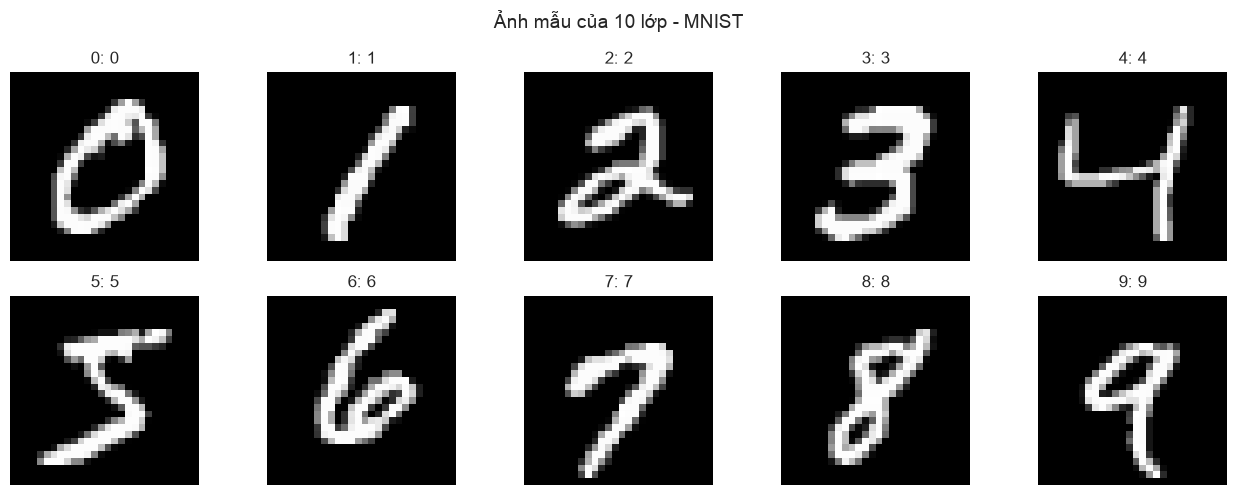

,class_id,class_name,train_count,test_count
0,0,0,5923,980
1,1,1,6742,1135
2,2,2,5958,1032
3,3,3,6131,1010
4,4,4,5842,982
5,5,5,5421,892
6,6,6,5918,958
7,7,7,6265,1028
8,8,8,5851,974
9,9,9,5949,1009


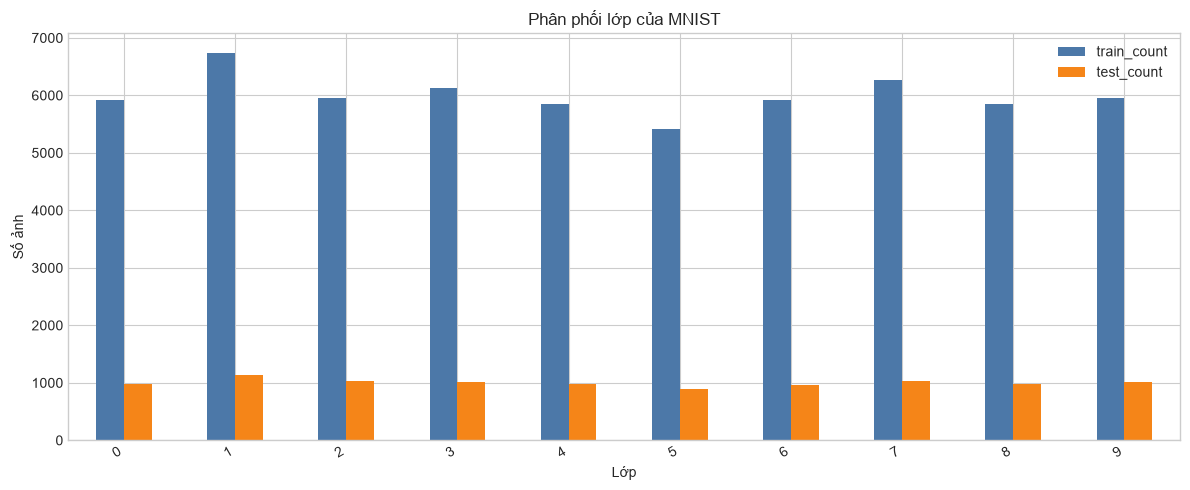

In [4]:
# Hiển thị một ảnh đại diện cho mỗi lớp.
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for label, ax in enumerate(axes.ravel()):
    image = x_train_full[np.flatnonzero(y_train_full == label)[0]]
    if image.shape[-1] == 1:
        ax.imshow(image.squeeze(-1), cmap="gray")
    else:
        ax.imshow(image)
    ax.set_title(f"{label}: {CLASS_NAMES[label]}")
    ax.axis("off")
fig.suptitle(f"Ảnh mẫu của 10 lớp - {DATASET_NAME}", fontsize=14)
plt.tight_layout()
plt.show()

train_counts = np.bincount(y_train_full, minlength=10)
test_counts = np.bincount(y_test_full, minlength=10)
distribution_df = pd.DataFrame({
    "class_id": np.arange(10),
    "class_name": CLASS_NAMES,
    "train_count": train_counts,
    "test_count": test_counts,
})
display(distribution_df)

ax = distribution_df.set_index("class_name")[["train_count", "test_count"]].plot(
    kind="bar", figsize=(12, 5), color=["#4C78A8", "#F58518"]
)
ax.set_title(f"Phân phối lớp của {DATASET_NAME}")
ax.set_xlabel("Lớp")
ax.set_ylabel("Số ảnh")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 7. Chia dữ liệu và chuẩn hóa

Train/validation được tách có `stratify`; test set chỉ dùng để đánh giá cuối. Mean/std được học duy nhất từ framework train set để tránh data leakage.

Với profile `accuracy`, Keras/PyTorch dùng toàn bộ phần train sau khi giữ validation; NumPy nhận một stratified subset của chính phần train đó. Mọi mô hình vẫn được chấm trên cùng full test set.

Cell này chia train/validation theo nhãn bằng stratified sampling, tạo subset riêng cho NumPy CNN và giữ nguyên test set để đánh giá cuối cùng. Mean và standard deviation chỉ được tính từ train set, sau đó dùng chung để chuẩn hóa validation/test, nhằm tránh rò rỉ thông tin.

In [5]:
def stratified_subset_indices(labels, limit, random_state):
    indices = np.arange(len(labels))
    if limit is None or limit >= len(indices):
        return indices
    selected, _ = train_test_split(
        indices,
        train_size=limit,
        random_state=random_state,
        stratify=labels,
    )
    return selected


def create_stratified_splits(y_train_all, y_test_all):
    all_train_indices = np.arange(len(y_train_all))
    all_test_indices = np.arange(len(y_test_all))

    if TRAIN_LIMIT is None:
        train_indices, validation_indices = train_test_split(
            all_train_indices,
            test_size=VALIDATION_SIZE,
            random_state=RANDOM_STATE,
            stratify=y_train_all,
        )
    else:
        selected_indices, _ = train_test_split(
            all_train_indices,
            train_size=TRAIN_LIMIT + VALIDATION_SIZE,
            random_state=RANDOM_STATE,
            stratify=y_train_all,
        )
        train_indices, validation_indices = train_test_split(
            selected_indices,
            train_size=TRAIN_LIMIT,
            test_size=VALIDATION_SIZE,
            random_state=RANDOM_STATE + 1,
            stratify=y_train_all[selected_indices],
        )

    test_indices = stratified_subset_indices(
        y_test_all,
        TEST_LIMIT,
        RANDOM_STATE,
    )
    return train_indices, validation_indices, test_indices


train_idx, val_idx, test_idx = create_stratified_splits(
    y_train_full,
    y_test_full,
)

x_train = x_train_full[train_idx].astype(np.float32) / 255.0
y_train = y_train_full[train_idx]
x_val = x_train_full[val_idx].astype(np.float32) / 255.0
y_val = y_train_full[val_idx]
x_test = x_test_full[test_idx].astype(np.float32) / 255.0
y_test = y_test_full[test_idx]

# Chỉ dùng thống kê của train để tránh data leakage.
channel_mean = x_train.mean(axis=(0, 1, 2), keepdims=True)
channel_std = x_train.std(axis=(0, 1, 2), keepdims=True) + 1e-7
x_train = (x_train - channel_mean) / channel_std
x_val = (x_val - channel_mean) / channel_std
x_test = (x_test - channel_mean) / channel_std

numpy_train_indices = stratified_subset_indices(
    y_train,
    NUMPY_TRAIN_LIMIT,
    RANDOM_STATE + 10,
)
numpy_val_indices = stratified_subset_indices(
    y_val,
    NUMPY_VALIDATION_LIMIT,
    RANDOM_STATE + 11,
)
x_train_numpy = x_train[numpy_train_indices]
y_train_numpy = y_train[numpy_train_indices]
x_val_numpy = x_val[numpy_val_indices]
y_val_numpy = y_val[numpy_val_indices]

split_df = pd.DataFrame({
    "split": ["framework train", "validation", "test", "NumPy train", "NumPy validation"],
    "samples": [
        len(y_train), len(y_val), len(y_test),
        len(y_train_numpy), len(y_val_numpy),
    ],
    "image_shape": [
        str(x_train.shape[1:]), str(x_val.shape[1:]), str(x_test.shape[1:]),
        str(x_train_numpy.shape[1:]), str(x_val_numpy.shape[1:]),
    ],
})
display(split_df)
print("Channel mean học từ train:", channel_mean.reshape(-1))
print("Channel std học từ train :", channel_std.reshape(-1))
print("Framework train counts   :", np.bincount(y_train, minlength=10))
print("NumPy train counts       :", np.bincount(y_train_numpy, minlength=10))

assert x_train.dtype == np.float32
assert x_train.shape[-1] in (1, 3)
assert np.isfinite(x_train).all()
assert np.isfinite(x_val).all()
assert np.isfinite(x_test).all()

,split,samples,image_shape
0,framework train,54000,"(28, 28, 1)"
1,validation,6000,"(28, 28, 1)"
2,test,10000,"(28, 28, 1)"
3,NumPy train,20000,"(28, 28, 1)"
4,NumPy validation,3000,"(28, 28, 1)"


Channel mean học từ train: [0.13073687]
Channel std học từ train : [0.30819046]
Framework train counts   : [5331 6068 5362 5518 5258 4879 5326 5638 5266 5354]
NumPy train counts       : [1975 2247 1986 2044 1947 1807 1973 2088 1950 1983]


## 8. Hàm đánh giá chung

Vì đây là phân loại đa lớp, notebook dùng Accuracy và Precision/Recall/F1 trung bình macro. Macro average cho mỗi lớp trọng số bằng nhau, nên không che giấu lớp yếu dù phân phối mẫu thay đổi.

Cell này định nghĩa cách tính Accuracy, Macro Precision, Macro Recall và Macro F1 từ xác suất dự đoán. Nó đồng thời khởi tạo các kho lưu kết quả, xác suất và lịch sử huấn luyện, giúp ba cách cài đặt được benchmark theo cùng một chuẩn.

In [6]:
def evaluate_predictions(
    model_name,
    y_true,
    probabilities,
    train_time,
    predict_time,
    parameters,
    train_samples,
    best_epoch,
    final_learning_rate,
):
    predictions = np.argmax(probabilities, axis=1)
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Macro Precision": precision_score(
            y_true, predictions, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_true, predictions, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_true, predictions, average="macro", zero_division=0
        ),
        "Train samples": int(train_samples),
        "Best epoch": int(best_epoch),
        "Final LR": float(final_learning_rate),
        "Parameters": int(parameters),
        "Train time (s)": float(train_time),
        "Predict time (s)": float(predict_time),
    }


benchmark_results = []
prediction_store = {}
history_store = {}

## 9. CNN from scratch bằng NumPy

Mạng NumPy mới có hai convolution block và hidden dense layer:

`Conv → ReLU → Pool → Conv → ReLU → Pool → Dense → ReLU → Dense → Softmax`.

Toàn bộ forward/backward, Adam, weight decay, gradient clipping, cosine learning rate và restore best weights đều được viết bằng NumPy, không dùng autograd. Random translation được áp dụng cho MNIST; CIFAR-10 có reflect-padding, random crop và horizontal flip.

Cell này tự cài đặt toàn bộ thành phần của CNN hai block: convolution, ReLU, max pooling, flatten, dense và softmax cross-entropy. Mỗi layer có cả `forward` lẫn `backward`; gradient được cập nhật bằng Adam kèm weight decay và gradient clipping, hoàn toàn không dùng autograd.

In [7]:
# ============================================================
# DEEPER CNN FROM SCRATCH - chỉ dùng NumPy
# Conv-ReLU-Pool -> Conv-ReLU-Pool -> Dense-ReLU -> Dense
# ============================================================

class Conv2D:
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        padding=1,
        random_state=42,
    ):
        self.kernel_size = kernel_size
        self.padding = padding
        rng = np.random.default_rng(random_state)
        fan_in = kernel_size * kernel_size * in_channels
        self.weight = rng.normal(
            0.0,
            np.sqrt(2.0 / fan_in),
            size=(kernel_size, kernel_size, in_channels, out_channels),
        ).astype(np.float32)
        self.bias = np.zeros(out_channels, dtype=np.float32)

    def _extract_patches(self, x):
        p = self.padding
        x_padded = np.pad(
            x,
            ((0, 0), (p, p), (p, p), (0, 0)),
            mode="constant",
        )
        windows = np.lib.stride_tricks.sliding_window_view(
            x_padded,
            (self.kernel_size, self.kernel_size),
            axis=(1, 2),
        )
        return x_padded, windows.transpose(0, 1, 2, 4, 5, 3)

    def forward(self, x):
        self.x_padded, self.patches = self._extract_patches(x)
        return (
            np.einsum(
                "nhwklc,klco->nhwo",
                self.patches,
                self.weight,
                optimize=True,
            )
            + self.bias
        )

    def backward(self, grad_output):
        self.grad_weight = np.einsum(
            "nhwklc,nhwo->klco",
            self.patches,
            grad_output,
            optimize=True,
        )
        self.grad_bias = grad_output.sum(axis=(0, 1, 2))
        grad_patches = np.einsum(
            "nhwo,klco->nhwklc",
            grad_output,
            self.weight,
            optimize=True,
        )

        grad_padded = np.zeros_like(self.x_padded)
        out_h, out_w = grad_output.shape[1:3]
        for row in range(self.kernel_size):
            for col in range(self.kernel_size):
                grad_padded[
                    :, row:row + out_h, col:col + out_w, :
                ] += grad_patches[:, :, :, row, col, :]

        p = self.padding
        return grad_padded if p == 0 else grad_padded[:, p:-p, p:-p, :]


class ReLU:
    def forward(self, x):
        self.mask = x > 0
        return np.maximum(x, 0)

    def backward(self, grad_output):
        return grad_output * self.mask


class MaxPool2D:
    def __init__(self, pool_size=2):
        self.pool_size = pool_size

    def forward(self, x):
        n, h, w, c = x.shape
        p = self.pool_size
        if h % p != 0 or w % p != 0:
            raise ValueError("Chiều cao/rộng phải chia hết cho pool_size.")
        self.input_shape = x.shape
        self.blocks = x.reshape(n, h // p, p, w // p, p, c)
        output = self.blocks.max(axis=(2, 4))
        self.max_mask = self.blocks == output[:, :, None, :, None, :]
        self.tie_count = self.max_mask.sum(axis=(2, 4), keepdims=True)
        return output

    def backward(self, grad_output):
        distributed = (
            self.max_mask
            * grad_output[:, :, None, :, None, :]
            / self.tie_count
        )
        return distributed.reshape(self.input_shape)


class Flatten:
    def forward(self, x):
        self.input_shape = x.shape
        return x.reshape(x.shape[0], -1)

    def backward(self, grad_output):
        return grad_output.reshape(self.input_shape)


class Linear:
    def __init__(self, in_features, out_features, random_state=43):
        rng = np.random.default_rng(random_state)
        self.weight = rng.normal(
            0.0,
            np.sqrt(2.0 / in_features),
            size=(in_features, out_features),
        ).astype(np.float32)
        self.bias = np.zeros(out_features, dtype=np.float32)

    def forward(self, x):
        self.input = x
        return x @ self.weight + self.bias

    def backward(self, grad_output):
        self.grad_weight = self.input.T @ grad_output
        self.grad_bias = grad_output.sum(axis=0)
        return grad_output @ self.weight.T


class SoftmaxCrossEntropy:
    def forward(self, logits, labels):
        shifted = logits - logits.max(axis=1, keepdims=True)
        exp_values = np.exp(shifted)
        self.probabilities = exp_values / exp_values.sum(
            axis=1,
            keepdims=True,
        )
        self.labels = labels.astype(np.int64)
        correct = self.probabilities[
            np.arange(len(labels)),
            self.labels,
        ]
        return float(-np.log(np.clip(correct, 1e-9, 1.0)).mean())

    def backward(self):
        gradient = self.probabilities.copy()
        gradient[np.arange(len(self.labels)), self.labels] -= 1.0
        return gradient / len(self.labels)


class NumpyAdam:
    def __init__(
        self,
        learning_rate=1e-3,
        weight_decay=1e-4,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
        gradient_clip=5.0,
    ):
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.gradient_clip = gradient_clip
        self.first_moment = {}
        self.second_moment = {}
        self.step_count = 0

    def step(self, named_parameters, learning_rate=None):
        self.step_count += 1
        lr = self.learning_rate if learning_rate is None else learning_rate
        for name, parameter, gradient, apply_decay in named_parameters:
            gradient = np.clip(
                gradient,
                -self.gradient_clip,
                self.gradient_clip,
            )
            if apply_decay:
                gradient = gradient + self.weight_decay * parameter

            if name not in self.first_moment:
                self.first_moment[name] = np.zeros_like(parameter)
                self.second_moment[name] = np.zeros_like(parameter)
            first = self.first_moment[name]
            second = self.second_moment[name]
            first *= self.beta1
            first += (1.0 - self.beta1) * gradient
            second *= self.beta2
            second += (1.0 - self.beta2) * gradient * gradient

            first_hat = first / (1.0 - self.beta1 ** self.step_count)
            second_hat = second / (1.0 - self.beta2 ** self.step_count)
            parameter -= lr * first_hat / (
                np.sqrt(second_hat) + self.epsilon
            )


class NumpyCNN:
    def __init__(
        self,
        input_shape,
        conv_filters=(8, 16),
        hidden_units=64,
        num_classes=10,
        random_state=42,
    ):
        height, width, channels = input_shape
        filters_1, filters_2 = conv_filters
        self.conv1 = Conv2D(
            channels,
            filters_1,
            random_state=random_state,
        )
        self.relu1 = ReLU()
        self.pool1 = MaxPool2D(2)
        self.conv2 = Conv2D(
            filters_1,
            filters_2,
            random_state=random_state + 1,
        )
        self.relu2 = ReLU()
        self.pool2 = MaxPool2D(2)
        self.flatten = Flatten()
        flattened_features = (
            (height // 4) * (width // 4) * filters_2
        )
        self.hidden = Linear(
            flattened_features,
            hidden_units,
            random_state=random_state + 2,
        )
        self.relu3 = ReLU()
        self.output = Linear(
            hidden_units,
            num_classes,
            random_state=random_state + 3,
        )

    def forward(self, x):
        x = self.pool1.forward(self.relu1.forward(self.conv1.forward(x)))
        x = self.pool2.forward(self.relu2.forward(self.conv2.forward(x)))
        x = self.flatten.forward(x)
        x = self.relu3.forward(self.hidden.forward(x))
        return self.output.forward(x)

    def backward(self, grad_logits):
        gradient = self.output.backward(grad_logits)
        gradient = self.relu3.backward(gradient)
        gradient = self.hidden.backward(gradient)
        gradient = self.flatten.backward(gradient)
        gradient = self.pool2.backward(gradient)
        gradient = self.relu2.backward(gradient)
        gradient = self.conv2.backward(gradient)
        gradient = self.pool1.backward(gradient)
        gradient = self.relu1.backward(gradient)
        return self.conv1.backward(gradient)

    def named_parameters(self):
        return [
            ("conv1.weight", self.conv1.weight, self.conv1.grad_weight, True),
            ("conv1.bias", self.conv1.bias, self.conv1.grad_bias, False),
            ("conv2.weight", self.conv2.weight, self.conv2.grad_weight, True),
            ("conv2.bias", self.conv2.bias, self.conv2.grad_bias, False),
            ("hidden.weight", self.hidden.weight, self.hidden.grad_weight, True),
            ("hidden.bias", self.hidden.bias, self.hidden.grad_bias, False),
            ("output.weight", self.output.weight, self.output.grad_weight, True),
            ("output.bias", self.output.bias, self.output.grad_bias, False),
        ]

    def state_dict(self):
        return {
            "conv1.weight": self.conv1.weight.copy(),
            "conv1.bias": self.conv1.bias.copy(),
            "conv2.weight": self.conv2.weight.copy(),
            "conv2.bias": self.conv2.bias.copy(),
            "hidden.weight": self.hidden.weight.copy(),
            "hidden.bias": self.hidden.bias.copy(),
            "output.weight": self.output.weight.copy(),
            "output.bias": self.output.bias.copy(),
        }

    def load_state_dict(self, state):
        self.conv1.weight[...] = state["conv1.weight"]
        self.conv1.bias[...] = state["conv1.bias"]
        self.conv2.weight[...] = state["conv2.weight"]
        self.conv2.bias[...] = state["conv2.bias"]
        self.hidden.weight[...] = state["hidden.weight"]
        self.hidden.bias[...] = state["hidden.bias"]
        self.output.weight[...] = state["output.weight"]
        self.output.bias[...] = state["output.bias"]

    def parameter_count(self):
        return sum(parameter.size for parameter in self.state_dict().values())


def softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum(axis=1, keepdims=True)


def augment_numpy_batch(images, rng, dataset_key):
    pad = 2 if dataset_key == "mnist" else 4
    height, width = images.shape[1:3]
    padded = np.pad(
        images,
        ((0, 0), (pad, pad), (pad, pad), (0, 0)),
        mode="reflect",
    )
    augmented = np.empty_like(images)
    top_offsets = rng.integers(0, 2 * pad + 1, size=len(images))
    left_offsets = rng.integers(0, 2 * pad + 1, size=len(images))
    for index, (top, left) in enumerate(
        zip(top_offsets, left_offsets)
    ):
        augmented[index] = padded[
            index,
            top:top + height,
            left:left + width,
            :,
        ]
    if dataset_key == "cifar10":
        flip_mask = rng.random(len(images)) < 0.5
        augmented[flip_mask] = augmented[flip_mask, :, ::-1, :]
    return augmented


def predict_numpy_proba(model, images, batch_size=128):
    batches = []
    for start in range(0, len(images), batch_size):
        logits = model.forward(images[start:start + batch_size])
        batches.append(softmax(logits))
    return np.concatenate(batches, axis=0)


def cosine_learning_rate(initial_lr, epoch, epochs, minimum_ratio=0.05):
    progress = epoch / max(1, epochs - 1)
    cosine = 0.5 * (1.0 + np.cos(np.pi * progress))
    return initial_lr * (minimum_ratio + (1.0 - minimum_ratio) * cosine)


def train_numpy_cnn(
    model,
    x_train_values,
    y_train_values,
    x_val_values,
    y_val_values,
    epochs,
    batch_size,
    learning_rate,
    weight_decay,
    dataset_key,
    random_state=42,
):
    criterion = SoftmaxCrossEntropy()
    optimizer = NumpyAdam(
        learning_rate=learning_rate,
        weight_decay=weight_decay,
    )
    rng = np.random.default_rng(random_state)
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "learning_rate": [],
    }
    best_loss = np.inf
    best_epoch = 0
    best_state = model.state_dict()

    for epoch in range(epochs):
        current_lr = cosine_learning_rate(
            learning_rate,
            epoch,
            epochs,
        )
        indices = rng.permutation(len(y_train_values))
        loss_sum = 0.0
        correct = 0

        for start in range(0, len(indices), batch_size):
            batch_indices = indices[start:start + batch_size]
            x_batch = augment_numpy_batch(
                x_train_values[batch_indices],
                rng,
                dataset_key,
            )
            y_batch = y_train_values[batch_indices]

            logits = model.forward(x_batch)
            loss = criterion.forward(logits, y_batch)
            model.backward(criterion.backward())
            optimizer.step(
                model.named_parameters(),
                learning_rate=current_lr,
            )
            loss_sum += loss * len(batch_indices)
            correct += np.sum(
                np.argmax(logits, axis=1) == y_batch
            )

        train_loss = loss_sum / len(y_train_values)
        train_accuracy = correct / len(y_train_values)
        val_probabilities = predict_numpy_proba(
            model,
            x_val_values,
            batch_size=batch_size,
        )
        val_correct = val_probabilities[
            np.arange(len(y_val_values)),
            y_val_values,
        ]
        val_loss = float(
            -np.log(np.clip(val_correct, 1e-9, 1.0)).mean()
        )
        val_accuracy = float(
            np.mean(
                np.argmax(val_probabilities, axis=1)
                == y_val_values
            )
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)
        history["learning_rate"].append(current_lr)

        if val_loss < best_loss:
            best_loss = val_loss
            best_epoch = epoch + 1
            best_state = model.state_dict()

        print(
            f"Epoch {epoch + 1:03d}/{epochs} | lr={current_lr:.6f} "
            f"| loss={train_loss:.4f} | acc={train_accuracy:.4f} "
            f"| val_loss={val_loss:.4f} | val_acc={val_accuracy:.4f}"
        )

    model.load_state_dict(best_state)
    history["best_epoch"] = best_epoch
    print(
        f"Restored NumPy weights from epoch {best_epoch} "
        f"(val_loss={best_loss:.4f})."
    )
    return history

### 9.1. Huấn luyện CNN NumPy

Cell này khởi tạo NumPy CNN cho shape ảnh MNIST, huấn luyện theo mini-batch và augmentation phù hợp với dataset. Learning rate giảm theo cosine; weights có validation loss tốt nhất được khôi phục trước khi dự đoán test. Cuối cell, metric, thời gian, số tham số và learning history được lưu cho phần so sánh.

In [8]:
numpy_model = NumpyCNN(
    input_shape=x_train_numpy.shape[1:],
    conv_filters=NUMPY_FILTERS,
    hidden_units=NUMPY_HIDDEN_UNITS,
    num_classes=10,
    random_state=RANDOM_STATE,
)
print("NumPy CNN parameters:", f"{numpy_model.parameter_count():,}")

start = time.perf_counter()
numpy_history = train_numpy_cnn(
    numpy_model,
    x_train_numpy,
    y_train_numpy,
    x_val_numpy,
    y_val_numpy,
    epochs=NUMPY_EPOCHS,
    batch_size=NUMPY_BATCH_SIZE,
    learning_rate=NUMPY_LEARNING_RATE,
    weight_decay=NUMPY_WEIGHT_DECAY,
    dataset_key=DATASET_KEY,
    random_state=RANDOM_STATE,
)
numpy_train_time = time.perf_counter() - start

start = time.perf_counter()
numpy_test_probabilities = predict_numpy_proba(
    numpy_model,
    x_test,
    batch_size=NUMPY_BATCH_SIZE,
)
numpy_predict_time = time.perf_counter() - start

benchmark_results.append(evaluate_predictions(
    "NumPy CNN from scratch",
    y_test,
    numpy_test_probabilities,
    numpy_train_time,
    numpy_predict_time,
    numpy_model.parameter_count(),
    len(y_train_numpy),
    numpy_history["best_epoch"],
    numpy_history["learning_rate"][-1],
))
prediction_store["NumPy CNN from scratch"] = numpy_test_probabilities
history_store["NumPy CNN from scratch"] = numpy_history
print(
    f"Train time: {numpy_train_time:.2f}s | Test accuracy: "
    f"{accuracy_score(y_test, np.argmax(numpy_test_probabilities, axis=1)):.4f}"
)

NumPy CNN parameters: 52,138
Epoch 001/15 | lr=0.001000 | loss=0.6155 | acc=0.8094 | val_loss=0.1477 | val_acc=0.9573
Epoch 002/15 | lr=0.000988 | loss=0.1949 | acc=0.9402 | val_loss=0.1124 | val_acc=0.9657
Epoch 003/15 | lr=0.000953 | loss=0.1435 | acc=0.9526 | val_loss=0.1138 | val_acc=0.9653
Epoch 004/15 | lr=0.000896 | loss=0.1152 | acc=0.9639 | val_loss=0.0868 | val_acc=0.9770
Epoch 005/15 | lr=0.000821 | loss=0.1075 | acc=0.9663 | val_loss=0.0727 | val_acc=0.9787
Epoch 006/15 | lr=0.000731 | loss=0.0897 | acc=0.9718 | val_loss=0.0800 | val_acc=0.9767
Epoch 007/15 | lr=0.000631 | loss=0.0808 | acc=0.9752 | val_loss=0.0737 | val_acc=0.9790
Epoch 008/15 | lr=0.000525 | loss=0.0736 | acc=0.9768 | val_loss=0.0701 | val_acc=0.9823
Epoch 009/15 | lr=0.000419 | loss=0.0672 | acc=0.9793 | val_loss=0.0605 | val_acc=0.9817
Epoch 010/15 | lr=0.000319 | loss=0.0622 | acc=0.9806 | val_loss=0.0593 | val_acc=0.9820
Epoch 011/15 | lr=0.000229 | loss=0.0542 | acc=0.9830 | val_loss=0.0592 | val_acc

## 10. CNN bằng TensorFlow/Keras

MNIST dùng CNN hai block với Batch Normalization, Dropout và AdamW. CIFAR-10 dùng CIFAR ResNet-20 chuẩn với ba residual stage `16 → 32 → 64`, Global Average Pooling, label smoothing, SGD momentum, warm-up và cosine decay.

Augmentation chỉ chạy trên train. Callback lưu weights có validation accuracy tốt nhất và khôi phục trước khi đánh giá test. CIFAR-10 huấn luyện cố định 50 epoch.

Cell này định nghĩa kiến trúc TensorFlow/Keras và biên dịch mô hình. Nhánh MNIST dùng hai convolution block kèm Batch Normalization/Dropout; nhánh CIFAR-10 dùng ResNet-20 với residual connection và Global Average Pooling. Cell cũng kiểm tra output của mô hình có 10 logits tương ứng 10 lớp.

In [9]:
def keras_residual_block(
    inputs,
    filters,
    stride,
    weight_decay,
    block_name,
):
    regularizer = keras.regularizers.l2(weight_decay)
    shortcut = inputs

    x = keras.layers.Conv2D(
        filters,
        3,
        strides=stride,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        kernel_regularizer=regularizer,
        name=block_name + "_conv1",
    )(inputs)
    x = keras.layers.BatchNormalization(
        name=block_name + "_bn1"
    )(x)
    x = keras.layers.ReLU(name=block_name + "_relu1")(x)
    x = keras.layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        kernel_regularizer=regularizer,
        name=block_name + "_conv2",
    )(x)
    x = keras.layers.BatchNormalization(
        name=block_name + "_bn2"
    )(x)

    if stride != 1 or int(inputs.shape[-1]) != filters:
        shortcut = keras.layers.Conv2D(
            filters,
            1,
            strides=stride,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal",
            kernel_regularizer=regularizer,
            name=block_name + "_shortcut_conv",
        )(shortcut)
        shortcut = keras.layers.BatchNormalization(
            name=block_name + "_shortcut_bn"
        )(shortcut)

    x = keras.layers.Add(name=block_name + "_add")([x, shortcut])
    return keras.layers.ReLU(name=block_name + "_out")(x)


def build_keras_cnn(input_shape, dataset_key):
    inputs = keras.layers.Input(shape=input_shape)

    if dataset_key == "mnist":
        x = inputs
        for block_index, filters in enumerate((32, 64), start=1):
            x = keras.layers.Conv2D(
                filters,
                3,
                padding="same",
                use_bias=False,
                kernel_initializer="he_normal",
                name=f"block{block_index}_conv1",
            )(x)
            x = keras.layers.BatchNormalization(
                name=f"block{block_index}_bn1"
            )(x)
            x = keras.layers.ReLU(
                name=f"block{block_index}_relu1"
            )(x)
            x = keras.layers.Conv2D(
                filters,
                3,
                padding="same",
                use_bias=False,
                kernel_initializer="he_normal",
                name=f"block{block_index}_conv2",
            )(x)
            x = keras.layers.BatchNormalization(
                name=f"block{block_index}_bn2"
            )(x)
            x = keras.layers.ReLU(
                name=f"block{block_index}_relu2"
            )(x)
            x = keras.layers.MaxPooling2D(
                2,
                name=f"block{block_index}_pool",
            )(x)
            x = keras.layers.Dropout(
                0.15 if block_index == 1 else 0.25,
                name=f"block{block_index}_dropout",
            )(x)
        x = keras.layers.Flatten(name="flatten")(x)
        x = keras.layers.Dense(
            128,
            activation="relu",
            kernel_initializer="he_normal",
            name="dense_features",
        )(x)
        x = keras.layers.Dropout(0.30, name="dense_dropout")(x)
        logits = keras.layers.Dense(10, name="logits")(x)
        model = keras.Model(inputs, logits, name="mnist_high_accuracy_cnn")
        optimizer = keras.optimizers.AdamW(
            learning_rate=1e-3,
            weight_decay=1e-4,
        )
        loss = keras.losses.SparseCategoricalCrossentropy(
            from_logits=True,
        )
        metrics = [
            keras.metrics.SparseCategoricalAccuracy(name="accuracy")
        ]
    else:
        regularizer = keras.regularizers.l2(5e-4)
        x = keras.layers.Conv2D(
            32,
            3,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal",
            kernel_regularizer=regularizer,
            name="stem_conv",
        )(inputs)
        x = keras.layers.BatchNormalization(name="stem_bn")(x)
        x = keras.layers.ReLU(name="stem_relu")(x)

        for stage_index, filters in enumerate((32, 64, 128)):
            for block_index in range(3):
                stride = (
                    2
                    if stage_index > 0 and block_index == 0
                    else 1
                )
                x = keras_residual_block(
                    x,
                    filters,
                    stride,
                    5e-4,
                    f"stage{stage_index + 1}_block{block_index + 1}",
                )

        x = keras.layers.GlobalAveragePooling2D(name="global_pool")(x)
        logits = keras.layers.Dense(
            10,
            kernel_regularizer=regularizer,
            name="logits",
        )(x)
        model = keras.Model(inputs, logits, name="cifar10_resnet20_w2")
        optimizer = keras.optimizers.SGD(
            learning_rate=0.02,
            momentum=0.9,
            nesterov=True,
        )
        loss = keras.losses.CategoricalCrossentropy(
            from_logits=True,
            label_smoothing=0.1,
        )
        metrics = [
            keras.metrics.CategoricalAccuracy(name="accuracy")
        ]

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=metrics,
    )
    return model


keras_model = build_keras_cnn(x_train.shape[1:], DATASET_KEY)
keras_model.summary()
sample_logits = keras_model(
    tf.zeros((2, *x_train.shape[1:])),
    training=False,
)
assert sample_logits.shape == (2, 10)

Model: "mnist_high_accuracy_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (ReLU)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (ReLU)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dropout (Dropout)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (ReLU)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (ReLU)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dropout (Dropout)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_features (Dense)          │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,394 (1.79 MB)

 Trainable params: 468,010 (1.79 MB)

 Non-trainable params: 384 (1.50 KB)

Cell này tạo `tf.data` pipeline, chỉ augmentation train set bằng dịch chuyển/crop và lật ngang khi phù hợp. Quá trình huấn luyện theo dõi validation accuracy, lưu best weights và áp dụng scheduler tương ứng dataset. Sau khi restore best weights, mô hình được đánh giá trên test set và ghi kết quả vào kho benchmark.

In [10]:
def augment_keras_image(image, label):
    height = tf.shape(image)[0]
    width = tf.shape(image)[1]
    pad = 2 if DATASET_KEY == "mnist" else 4
    image = tf.pad(
        image,
        [[pad, pad], [pad, pad], [0, 0]],
        mode="REFLECT",
    )
    image = tf.image.random_crop(
        image,
        size=(height, width, x_train.shape[-1]),
    )
    if DATASET_KEY == "cifar10":
        image = tf.image.random_flip_left_right(image)
    return image, label


def make_keras_dataset(
    images,
    labels,
    training,
):
    if DATASET_KEY == "cifar10":
        labels = keras.utils.to_categorical(labels, num_classes=10)
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    if training:
        dataset = dataset.shuffle(
            min(len(images), 10000),
            seed=RANDOM_STATE,
            reshuffle_each_iteration=True,
        )
        @tf.autograph.experimental.do_not_convert
        def augmentation_map(image, label):
            return augment_keras_image(
                image,
                label,
            )

        dataset = dataset.map(
            augmentation_map,
            num_parallel_calls=tf.data.AUTOTUNE,
        )
    return dataset.batch(
        FRAMEWORK_BATCH_SIZE,
    ).prefetch(tf.data.AUTOTUNE)


class BestKerasWeights(keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.best_accuracy = -np.inf
        self.best_epoch = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        accuracy = float((logs or {}).get("val_accuracy", -np.inf))
        if accuracy > self.best_accuracy:
            self.best_accuracy = accuracy
            self.best_epoch = epoch + 1
            self.best_weights = self.model.get_weights()

    def restore(self):
        if self.best_weights is None:
            raise RuntimeError("Không có Keras best weights để khôi phục.")
        self.model.set_weights(self.best_weights)


def cifar_keras_lr(epoch, current_lr=None):
    if epoch < 5:
        return 0.02 + (0.10 - 0.02) * (epoch + 1) / 5
    progress = (epoch - 5) / max(1, FRAMEWORK_EPOCHS - 5)
    return 1e-4 + 0.5 * (0.10 - 1e-4) * (
        1.0 + np.cos(np.pi * progress)
    )





def merge_keras_history(target, fit_history):
    mapping = {
        "loss": "train_loss",
        "val_loss": "val_loss",
        "accuracy": "train_accuracy",
        "val_accuracy": "val_accuracy",
    }
    for source_key, target_key in mapping.items():
        target[target_key].extend(
            [float(value) for value in fit_history.history[source_key]]
        )


keras_train_dataset = make_keras_dataset(
    x_train,
    y_train,
    training=True,
)
keras_val_dataset = make_keras_dataset(
    x_val,
    y_val,
    training=False,
)
keras_history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "learning_rate": [],
}
keras_best = BestKerasWeights()

if DATASET_KEY == "mnist":
    keras_callbacks = [
        keras_best,
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_accuracy",
            mode="max",
            factor=0.3,
            patience=2,
            min_lr=1e-5,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=4,
            verbose=1,
        ),
    ]
else:
    keras_callbacks = [
        keras_best,
        keras.callbacks.LearningRateScheduler(
            cifar_keras_lr,
            verbose=0,
        ),
    ]

start = time.perf_counter()
keras_fit = keras_model.fit(
    keras_train_dataset,
    validation_data=keras_val_dataset,
    epochs=FRAMEWORK_EPOCHS,
    callbacks=keras_callbacks,
    verbose=2,
)
merge_keras_history(keras_history, keras_fit)



keras_train_time = time.perf_counter() - start
keras_best.restore()
keras_history["best_epoch"] = keras_best.best_epoch
keras_history["learning_rate"] = [
    cifar_keras_lr(epoch)
    if DATASET_KEY == "cifar10"
    else np.nan
    for epoch in range(len(keras_history["train_loss"]))
]

start = time.perf_counter()
keras_test_logits = keras_model.predict(
    x_test,
    batch_size=FRAMEWORK_BATCH_SIZE,
    verbose=0,
)
keras_test_probabilities = tf.nn.softmax(
    keras_test_logits,
    axis=1,
).numpy()
keras_predict_time = time.perf_counter() - start
keras_final_lr = float(
    keras.backend.get_value(keras_model.optimizer.learning_rate)
)

benchmark_results.append(evaluate_predictions(
    "TensorFlow/Keras CNN",
    y_test,
    keras_test_probabilities,
    keras_train_time,
    keras_predict_time,
    keras_model.count_params(),
    len(y_train),
    keras_best.best_epoch,
    keras_final_lr,
))
prediction_store["TensorFlow/Keras CNN"] = keras_test_probabilities
history_store["TensorFlow/Keras CNN"] = keras_history
print(
    f"Restored Keras epoch {keras_best.best_epoch} "
    f"(val_acc={keras_best.best_accuracy:.4f})."
)
print(
    f"Train time: {keras_train_time:.2f}s | Test accuracy: "
    f"{accuracy_score(y_test, np.argmax(keras_test_probabilities, axis=1)):.4f}"
)

Epoch 1/15
422/422 - 27s - 65ms/step - accuracy: 0.8520 - loss: 0.4598 - val_accuracy: 0.9800 - val_loss: 0.0702 - learning_rate: 0.0010
Epoch 2/15
422/422 - 27s - 64ms/step - accuracy: 0.9587 - loss: 0.1374 - val_accuracy: 0.9792 - val_loss: 0.0758 - learning_rate: 0.0010
Epoch 3/15
422/422 - 27s - 64ms/step - accuracy: 0.9690 - loss: 0.1051 - val_accuracy: 0.9818 - val_loss: 0.0605 - learning_rate: 0.0010
Epoch 4/15
422/422 - 26s - 62ms/step - accuracy: 0.9744 - loss: 0.0857 - val_accuracy: 0.9872 - val_loss: 0.0416 - learning_rate: 0.0010
Epoch 5/15
422/422 - 27s - 64ms/step - accuracy: 0.9746 - loss: 0.0815 - val_accuracy: 0.9883 - val_loss: 0.0372 - learning_rate: 0.0010
Epoch 6/15
422/422 - 27s - 63ms/step - accuracy: 0.9781 - loss: 0.0699 - val_accuracy: 0.9902 - val_loss: 0.0342 - learning_rate: 0.0010
Epoch 7/15
422/422 - 27s - 63ms/step - accuracy: 0.9808 - loss: 0.0661 - val_accuracy: 0.9897 - val_loss: 0.0365 - learning_rate: 0.0010
Epoch 8/15

Epoch 8: ReduceLROnPlateau re

E0000 00:00:1789438817.869212 5730351 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Restored Keras epoch 13 (val_acc=0.9937).
Train time: 399.87s | Test accuracy: 0.9955


## 11. CNN bằng PyTorch

PyTorch triển khai kiến trúc và chính sách huấn luyện tương đương Keras. Augmentation được viết trực tiếp bằng tensor, không cần `torchvision`. Training loop lưu state tốt nhất theo validation accuracy và tự chọn CUDA, MPS hoặc CPU.

Cell này kiểm tra PyTorch, chọn thiết bị theo thứ tự CUDA → MPS → CPU, sau đó định nghĩa kiến trúc tương ứng với bản Keras. Trọng số convolution/linear được khởi tạo theo He initialization; output thử được kiểm tra có shape `(batch, 10)`.

In [11]:
if not TORCH_AVAILABLE:
    raise ModuleNotFoundError(
        "Phần PyTorch cần package `torch`. "
        "Hãy cài vào kernel ISD, restart kernel rồi Run All."
    )

import copy
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("PyTorch device:", DEVICE)


class TorchResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            3,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, inputs):
        residual = self.shortcut(inputs)
        output = self.relu(self.bn1(self.conv1(inputs)))
        output = self.bn2(self.conv2(output))
        return self.relu(output + residual)


class TorchCNN(nn.Module):
    def __init__(self, input_shape, dataset_key):
        super().__init__()
        height, width, channels = input_shape
        self.dataset_key = dataset_key

        if dataset_key == "mnist":
            self.features = nn.Sequential(
                nn.Conv2d(channels, 32, 3, padding=1, bias=False),
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.Conv2d(32, 32, 3, padding=1, bias=False),
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Dropout(0.15),
                nn.Conv2d(32, 64, 3, padding=1, bias=False),
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.Conv2d(64, 64, 3, padding=1, bias=False),
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Dropout(0.25),
            )
            flattened_features = (height // 4) * (width // 4) * 64
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(flattened_features, 128),
                nn.ReLU(),
                nn.Dropout(0.30),
                nn.Linear(128, 10),
            )
        else:
            self.stem = nn.Sequential(
                nn.Conv2d(channels, 32, 3, padding=1, bias=False),
                nn.BatchNorm2d(32),
                nn.ReLU(),
            )
            self.stage1 = self._make_stage(32, 32, blocks=3, stride=1)
            self.stage2 = self._make_stage(32, 64, blocks=3, stride=2)
            self.stage3 = self._make_stage(64, 128, blocks=3, stride=2)
            self.classifier = nn.Linear(128, 10)

        self.apply(self._initialize)

    @staticmethod
    def _make_stage(
        in_channels,
        out_channels,
        blocks,
        stride,
    ):
        layers = [
            TorchResidualBlock(
                in_channels,
                out_channels,
                stride=stride,
            )
        ]
        layers.extend(
            TorchResidualBlock(out_channels, out_channels)
            for _ in range(blocks - 1)
        )
        return nn.Sequential(*layers)

    @staticmethod
    def _initialize(module):
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(
                module.weight,
                mode="fan_out",
                nonlinearity="relu",
            )
        elif isinstance(module, nn.BatchNorm2d):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Linear):
            nn.init.kaiming_normal_(
                module.weight,
                nonlinearity="relu",
            )
            nn.init.zeros_(module.bias)

    def forward(self, inputs):
        if self.dataset_key == "mnist":
            return self.classifier(self.features(inputs))
        output = self.stem(inputs)
        output = self.stage1(output)
        output = self.stage2(output)
        output = self.stage3(output)
        output = F.adaptive_avg_pool2d(output, 1).flatten(1)
        return self.classifier(output)


torch_model = TorchCNN(
    x_train.shape[1:],
    DATASET_KEY,
).to(DEVICE)
torch_parameters = sum(
    parameter.numel()
    for parameter in torch_model.parameters()
)
with torch.no_grad():
    sample_output = torch_model(
        torch.zeros(
            2,
            x_train.shape[-1],
            x_train.shape[1],
            x_train.shape[2],
            device=DEVICE,
        )
    )
assert sample_output.shape == (2, 10)
print(torch_model)
print("PyTorch CNN parameters:", f"{torch_parameters:,}")

PyTorch device: mps
TorchCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.15, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (13): ReLU()
    (

Cell này chuyển ảnh sang định dạng channels-first, tạo `DataLoader` và thực hiện augmentation trực tiếp trên tensor mà không cần `torchvision`. Training loop gồm optimizer, learning-rate schedule, gradient clipping, validation sau mỗi epoch và lưu best state. Cuối cùng, best state được khôi phục để dự đoán test và lưu metric benchmark.

In [12]:
def to_torch_dataset(images, labels):
    channels_first = np.transpose(images, (0, 3, 1, 2)).copy()
    return TensorDataset(
        torch.from_numpy(channels_first).float(),
        torch.from_numpy(labels).long(),
    )


def augment_torch_batch(images, dataset_key):
    max_shift = 2 if dataset_key == "mnist" else 4
    batch_size, _, height, width = images.shape
    translations = torch.randint(
        -max_shift,
        max_shift + 1,
        (batch_size, 2),
        device=images.device,
    )
    theta = torch.zeros(
        batch_size,
        2,
        3,
        dtype=images.dtype,
        device=images.device,
    )
    theta[:, 0, 0] = 1.0
    theta[:, 1, 1] = 1.0
    theta[:, 0, 2] = 2.0 * translations[:, 1] / width
    theta[:, 1, 2] = 2.0 * translations[:, 0] / height
    grid = F.affine_grid(
        theta,
        images.size(),
        align_corners=False,
    )
    augmented = F.grid_sample(
        images,
        grid,
        mode="bilinear",
        padding_mode="reflection",
        align_corners=False,
    )

    if dataset_key == "cifar10":
        flip_mask = torch.rand(
            batch_size,
            device=images.device,
        ) < 0.5
        augmented = torch.where(
            flip_mask[:, None, None, None],
            torch.flip(augmented, dims=(3,)),
            augmented,
        )
    return augmented


generator = torch.Generator().manual_seed(RANDOM_STATE)
train_loader = DataLoader(
    to_torch_dataset(x_train, y_train),
    batch_size=FRAMEWORK_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    generator=generator,
)
val_loader = DataLoader(
    to_torch_dataset(x_val, y_val),
    batch_size=FRAMEWORK_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    to_torch_dataset(x_test, y_test),
    batch_size=FRAMEWORK_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)


def evaluate_torch_loader(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = model(images)
            total_loss += criterion(logits, labels).item() * len(labels)
            correct += (
                logits.argmax(dim=1) == labels
            ).sum().item()
            total += len(labels)
    return total_loss / total, correct / total


def cifar_torch_lr(epoch):
    if epoch < 5:
        return 0.02 + (0.10 - 0.02) * (epoch + 1) / 5
    progress = (epoch - 5) / max(1, FRAMEWORK_EPOCHS - 5)
    return 1e-4 + 0.5 * (0.10 - 1e-4) * (
        1.0 + np.cos(np.pi * progress)
    )





def train_torch_phase(
    model,
    train_data_loader,
    validation_data_loader,
    optimizer,
    criterion,
    history,
    best,
    start_epoch,
    end_epoch,
    plateau_scheduler=None,
):
    for epoch in range(start_epoch, end_epoch):
        if DATASET_KEY == "cifar10":
            current_lr = cifar_torch_lr(epoch)
            for group in optimizer.param_groups:
                group["lr"] = current_lr
        else:
            current_lr = optimizer.param_groups[0]["lr"]

        model.train()
        loss_sum = 0.0
        correct = 0
        total = 0
        for images, labels in train_data_loader:
            images = augment_torch_batch(
                images,
                DATASET_KEY,
            )
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0,
            )
            optimizer.step()

            loss_sum += loss.item() * len(labels)
            correct += (
                logits.argmax(dim=1) == labels
            ).sum().item()
            total += len(labels)

        train_loss = loss_sum / total
        train_accuracy = correct / total
        val_loss, val_accuracy = evaluate_torch_loader(
            model,
            validation_data_loader,
            criterion,
        )
        if plateau_scheduler is not None:
            plateau_scheduler.step(val_accuracy)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)
        history["learning_rate"].append(current_lr)

        if val_accuracy > best["accuracy"]:
            best["accuracy"] = val_accuracy
            best["epoch"] = epoch + 1
            best["state"] = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch + 1:03d}/{end_epoch} | lr={current_lr:.6f} "
            f"| loss={train_loss:.4f} | acc={train_accuracy:.4f} "
            f"| val_loss={val_loss:.4f} | val_acc={val_accuracy:.4f}"
        )


if DATASET_KEY == "mnist":
    torch_optimizer = torch.optim.AdamW(
        torch_model.parameters(),
        lr=1e-3,
        weight_decay=1e-4,
    )
    torch_criterion = nn.CrossEntropyLoss()
    torch_plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
        torch_optimizer,
        mode="max",
        factor=0.3,
        patience=2,
        min_lr=1e-5,
    )
else:
    torch_optimizer = torch.optim.SGD(
        torch_model.parameters(),
        lr=0.02,
        momentum=0.9,
        nesterov=True,
        weight_decay=5e-4,
    )
    torch_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    torch_plateau = None

torch_history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "learning_rate": [],
}
torch_best = {
    "accuracy": -np.inf,
    "epoch": 0,
    "state": None,
}

start = time.perf_counter()
train_torch_phase(
    torch_model,
    train_loader,
    val_loader,
    torch_optimizer,
    torch_criterion,
    torch_history,
    torch_best,
    start_epoch=0,
    end_epoch=FRAMEWORK_EPOCHS,
    plateau_scheduler=torch_plateau,
)



torch_train_time = time.perf_counter() - start
if torch_best["state"] is None:
    raise RuntimeError("Không có PyTorch best weights để khôi phục.")
torch_model.load_state_dict(torch_best["state"])
torch_history["best_epoch"] = torch_best["epoch"]


def predict_torch_proba(model, loader):
    model.eval()
    batches = []
    with torch.no_grad():
        for images, _ in loader:
            logits = model(images.to(DEVICE))
            batches.append(
                torch.softmax(logits, dim=1).cpu().numpy()
            )
    return np.concatenate(batches, axis=0)


start = time.perf_counter()
torch_test_probabilities = predict_torch_proba(
    torch_model,
    test_loader,
)
torch_predict_time = time.perf_counter() - start

benchmark_results.append(evaluate_predictions(
    "PyTorch CNN",
    y_test,
    torch_test_probabilities,
    torch_train_time,
    torch_predict_time,
    torch_parameters,
    len(y_train),
    torch_best["epoch"],
    torch_history["learning_rate"][-1],
))
prediction_store["PyTorch CNN"] = torch_test_probabilities
history_store["PyTorch CNN"] = torch_history
print(
    f"Restored PyTorch epoch {torch_best['epoch']} "
    f"(val_acc={torch_best['accuracy']:.4f})."
)
print(
    f"Train time: {torch_train_time:.2f}s | Test accuracy: "
    f"{accuracy_score(y_test, np.argmax(torch_test_probabilities, axis=1)):.4f}"
)

Epoch 001/15 | lr=0.001000 | loss=0.4578 | acc=0.8629 | val_loss=0.0704 | val_acc=0.9788
Epoch 002/15 | lr=0.001000 | loss=0.1410 | acc=0.9586 | val_loss=0.0653 | val_acc=0.9832
Epoch 003/15 | lr=0.001000 | loss=0.1071 | acc=0.9685 | val_loss=0.0457 | val_acc=0.9875
Epoch 004/15 | lr=0.001000 | loss=0.0920 | acc=0.9732 | val_loss=0.0431 | val_acc=0.9878
Epoch 005/15 | lr=0.001000 | loss=0.0841 | acc=0.9747 | val_loss=0.0366 | val_acc=0.9887
Epoch 006/15 | lr=0.001000 | loss=0.0716 | acc=0.9788 | val_loss=0.0348 | val_acc=0.9903
Epoch 007/15 | lr=0.001000 | loss=0.0647 | acc=0.9809 | val_loss=0.0339 | val_acc=0.9900
Epoch 008/15 | lr=0.001000 | loss=0.0631 | acc=0.9814 | val_loss=0.0417 | val_acc=0.9887
Epoch 009/15 | lr=0.001000 | loss=0.0548 | acc=0.9840 | val_loss=0.0310 | val_acc=0.9910
Epoch 010/15 | lr=0.001000 | loss=0.0546 | acc=0.9840 | val_loss=0.0334 | val_acc=0.9912
Epoch 011/15 | lr=0.001000 | loss=0.0546 | acc=0.9837 | val_loss=0.0289 | val_acc=0.9898
Epoch 012/15 | lr=0.0

## 12. Learning curves

So sánh train/validation loss và accuracy giúp nhận ra underfitting hoặc overfitting. Do NumPy và framework có số epoch khác nhau, trục epoch được đọc riêng cho từng cột.

Cell này đọc history của từng mô hình để vẽ train/validation loss và accuracy theo epoch. Đường dọc đỏ đánh dấu best epoch đã được chọn, giúp nhận biết underfitting, overfitting và tốc độ hội tụ.

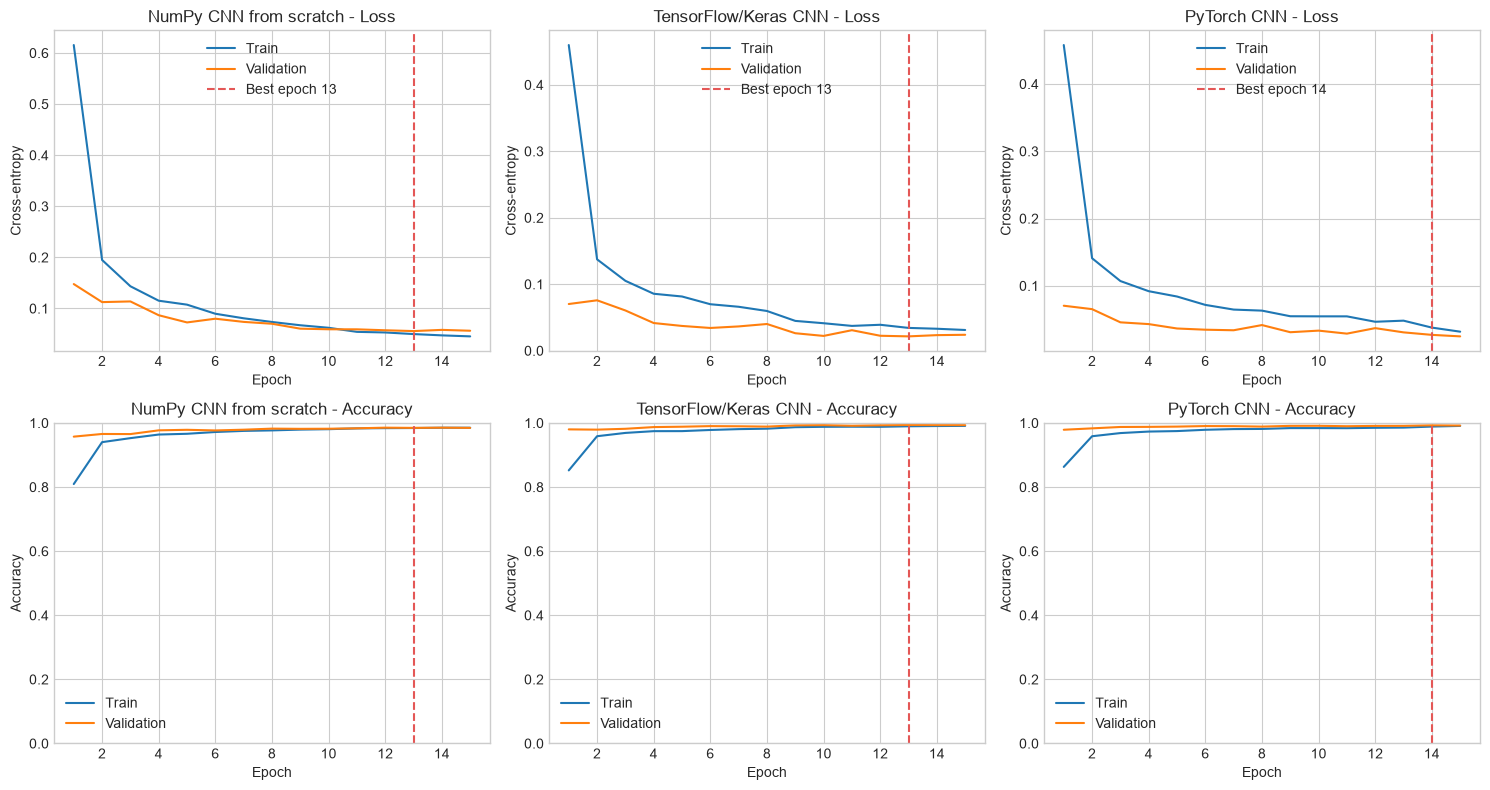

In [13]:
model_names = list(history_store)
fig, axes = plt.subplots(
    2,
    len(model_names),
    figsize=(5 * len(model_names), 8),
    squeeze=False,
)

for column, model_name in enumerate(model_names):
    history = history_store[model_name]
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    best_epoch = int(history["best_epoch"])

    axes[0, column].plot(
        epochs,
        history["train_loss"],
        label="Train",
    )
    axes[0, column].plot(
        epochs,
        history["val_loss"],
        label="Validation",
    )
    axes[0, column].axvline(
        best_epoch,
        color="#E45756",
        linestyle="--",
        label=f"Best epoch {best_epoch}",
    )
    axes[0, column].set_title(model_name + " - Loss")
    axes[0, column].set_xlabel("Epoch")
    axes[0, column].set_ylabel("Cross-entropy")
    axes[0, column].legend()

    axes[1, column].plot(
        epochs,
        history["train_accuracy"],
        label="Train",
    )
    axes[1, column].plot(
        epochs,
        history["val_accuracy"],
        label="Validation",
    )
    axes[1, column].axvline(
        best_epoch,
        color="#E45756",
        linestyle="--",
    )
    axes[1, column].set_title(model_name + " - Accuracy")
    axes[1, column].set_xlabel("Epoch")
    axes[1, column].set_ylabel("Accuracy")
    axes[1, column].set_ylim(0, 1)
    axes[1, column].legend()

plt.tight_layout()
plt.show()

## 13. Benchmark ba mô hình

Các score được tính trên cùng test subset. Thời gian phụ thuộc phần cứng và lần khởi động framework, vì vậy chỉ nên xem là tham khảo trong chính lần chạy notebook này.

Cell này chuyển kết quả của ba mô hình thành bảng, sắp xếp theo Macro F1 và Accuracy, rồi vẽ biểu đồ cột so sánh các metric trên MNIST. Bảng cũng thể hiện số mẫu train, best epoch, learning rate cuối, số tham số và thời gian chạy.

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Train samples,Best epoch,Final LR,Parameters,Train time (s),Predict time (s)
0,PyTorch CNN,0.9958,0.9959,0.9958,0.9958,"54,000",14,0.000300,"468,010",90.38,0.307
1,TensorFlow/Keras CNN,0.9955,0.9955,0.9955,0.9955,"54,000",13,0.000027,"468,394",399.87,1.183
2,NumPy CNN from scratch,0.9848,0.9847,0.9847,0.9847,"20,000",13,0.000050,"52,138",82.86,1.094


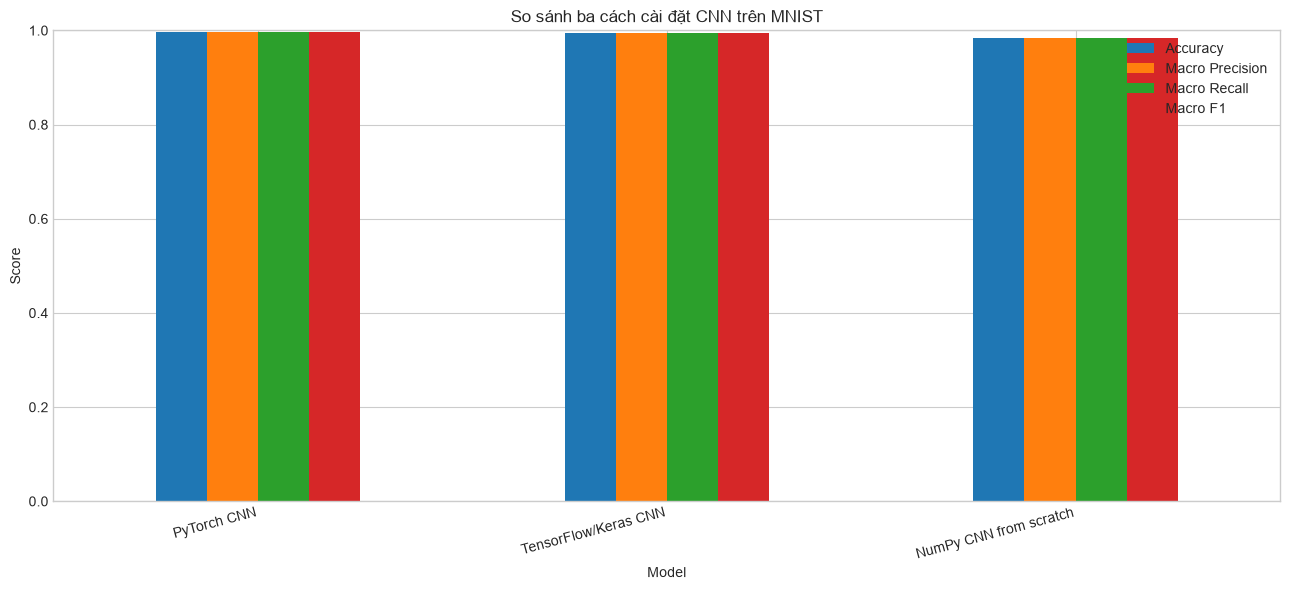

In [14]:
ordered_columns = [
    "Model",
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Train samples",
    "Best epoch",
    "Final LR",
    "Parameters",
    "Train time (s)",
    "Predict time (s)",
]
results_df = pd.DataFrame(benchmark_results)[ordered_columns]
results_df = results_df.sort_values(
    ["Macro F1", "Accuracy"],
    ascending=False,
).reset_index(drop=True)
display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Macro Precision": "{:.4f}",
    "Macro Recall": "{:.4f}",
    "Macro F1": "{:.4f}",
    "Train samples": "{:,}",
    "Best epoch": "{:d}",
    "Final LR": "{:.6f}",
    "Parameters": "{:,}",
    "Train time (s)": "{:.2f}",
    "Predict time (s)": "{:.3f}",
}))

metric_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
]
ax = results_df.set_index("Model")[metric_columns].plot(
    kind="bar",
    figsize=(13, 6),
)
ax.set_title(
    f"So sánh ba cách cài đặt CNN trên {DATASET_NAME}"
)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 14. Confusion matrix chuẩn hóa

Mỗi hàng ứng với một lớp thật và có tổng bằng 1. Đường chéo càng đậm càng tốt; các ô ngoài đường chéo cho biết cặp lớp thường bị nhầm.

Cell này tạo confusion matrix cho từng mô hình và chuẩn hóa theo nhãn thật. Mỗi hàng thể hiện tỷ lệ mẫu của một lớp được phân loại sang các lớp khác, qua đó cho thấy những cặp lớp mô hình dễ nhầm lẫn.

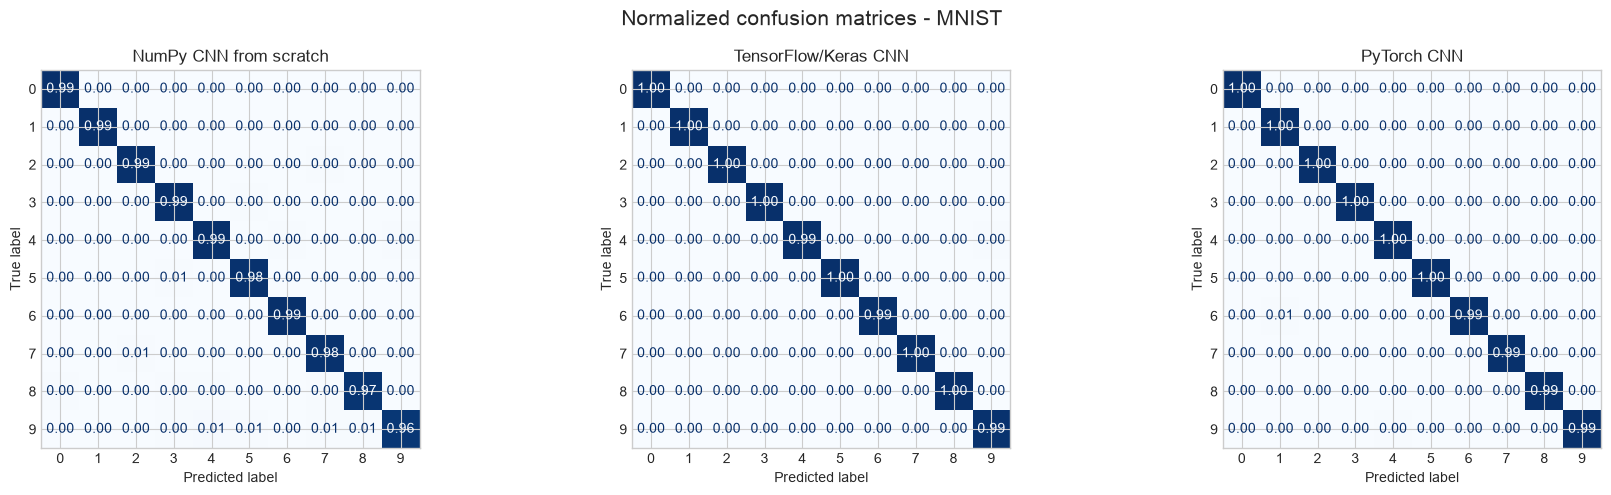

In [15]:
fig, axes = plt.subplots(
    1,
    len(prediction_store),
    figsize=(6 * len(prediction_store), 5),
    squeeze=False,
)
for ax, (model_name, probabilities) in zip(
    axes.ravel(),
    prediction_store.items(),
):
    predictions = np.argmax(probabilities, axis=1)
    matrix = confusion_matrix(
        y_test,
        predictions,
        labels=np.arange(10),
        normalize="true",
    )
    display_matrix = ConfusionMatrixDisplay(
        matrix,
        display_labels=np.arange(10),
    )
    display_matrix.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format=".2f",
    )
    ax.set_title(model_name)
fig.suptitle(
    f"Normalized confusion matrices - {DATASET_NAME}",
    fontsize=15,
)
plt.tight_layout()
plt.show()

## 15. Phân tích lỗi

Chọn mô hình có Macro F1 cao nhất, tính accuracy theo từng lớp và hiển thị các dự đoán sai có confidence cao nhất.

Cell này chọn mô hình có kết quả tốt nhất, tách các dự đoán đúng/sai và sắp xếp lỗi theo confidence. Các ảnh sai nhưng có confidence cao được hiển thị để phân tích những trường hợp mô hình tự tin nhưng phân loại không chính xác.

Best model: PyTorch CNN


,class_id,class_name,samples,accuracy
0,0,0,980,0.9990
1,1,1,1135,0.9974
2,2,2,1032,0.9971
3,3,3,1010,0.9960
4,4,4,982,0.9990
5,5,5,892,0.9955
6,6,6,958,0.9927
7,7,7,1028,0.9942
8,8,8,974,0.9949
9,9,9,1009,0.9921


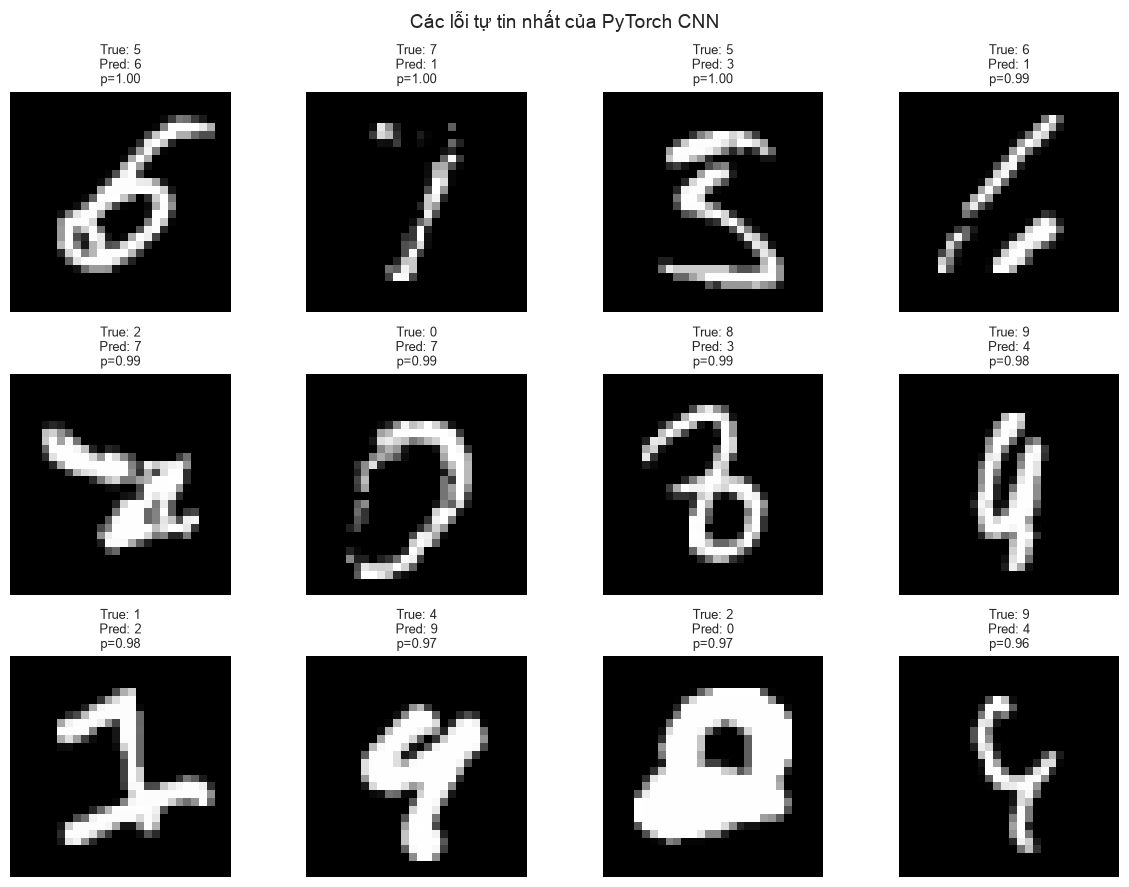

In [16]:
best_model_name = results_df.iloc[0]["Model"]
best_probabilities = prediction_store[best_model_name]
best_predictions = np.argmax(best_probabilities, axis=1)

per_class_rows = []
for class_id, class_name in enumerate(CLASS_NAMES):
    class_mask = y_test == class_id
    per_class_rows.append({
        "class_id": class_id,
        "class_name": class_name,
        "samples": int(class_mask.sum()),
        "accuracy": float(
            np.mean(best_predictions[class_mask] == class_id)
        ),
    })
print("Best model:", best_model_name)
display(
    pd.DataFrame(per_class_rows).style.format({"accuracy": "{:.4f}"})
)

wrong_indices = np.flatnonzero(best_predictions != y_test)
confidence = best_probabilities[
    np.arange(len(y_test)),
    best_predictions,
]
wrong_indices = wrong_indices[
    np.argsort(confidence[wrong_indices])[::-1]
][:12]

if len(wrong_indices) == 0:
    print("Không có dự đoán sai trong test subset.")
else:
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    for ax, index in zip(axes.ravel(), wrong_indices):
        raw_image = x_test_full[test_idx[index]]
        if raw_image.shape[-1] == 1:
            ax.imshow(raw_image.squeeze(-1), cmap="gray")
        else:
            ax.imshow(raw_image)
        true_name = CLASS_NAMES[y_test[index]]
        predicted_name = CLASS_NAMES[best_predictions[index]]
        ax.set_title(
            f"True: {true_name}\nPred: {predicted_name}"
            f"\np={confidence[index]:.2f}",
            fontsize=9,
        )
        ax.axis("off")
    for ax in axes.ravel()[len(wrong_indices):]:
        ax.axis("off")
    fig.suptitle(
        f"Các lỗi tự tin nhất của {best_model_name}",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

## 16. Kết luận

- NumPy CNN hai block minh họa đầy đủ forward/backward thủ công, Adam, regularization và data augmentation.
- MNIST hưởng lợi từ full data, Batch Normalization và restore best weights.
- CIFAR-10 cần residual connection, augmentation, regularization và lịch learning rate dài để hạn chế underfitting.
- Bảng benchmark cho phép so sánh accuracy, Macro-F1, số tham số và thời gian chạy của ba cách cài đặt.

Cell cuối cùng rút ra hai thông tin chính từ bảng benchmark: mô hình có Macro F1 cao nhất và mô hình có thời gian huấn luyện ngắn nhất. Hai tiêu chí này phân biệt rõ chất lượng phân loại và chi phí tính toán.

In [17]:
best_by_f1 = results_df.iloc[0]
fastest = results_df.sort_values("Train time (s)").iloc[0]

print(
    f"Mô hình có Macro F1 tốt nhất: {best_by_f1['Model']} "
    f"({best_by_f1['Macro F1']:.4f})"
)
print(
    f"Mô hình train nhanh nhất: {fastest['Model']} "
    f"({fastest['Train time (s)']:.2f}s)"
)

Mô hình có Macro F1 tốt nhất: PyTorch CNN (0.9958)
Mô hình train nhanh nhất: NumPy CNN from scratch (82.86s)
